In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load CSV file
data = pd.read_csv("Cod_cwl_data.csv")

# Display first rows
data.head()

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_14322/1110810670.py:2: DtypeWarning: Columns (0: match id, 1: avg time per life (s), 2: fave specialist, 3: fave scorestreaks, 4: fave division, 5: fave training) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Cod_cwl_data.csv")


,Unnamed: 0,match id,series id,end time,duration (s),mode,map,team,player,win?,score,kills,deaths,+/-,k/d,kills per 10min,deaths per 10min,player score,player spm,damage dealt,ekia,assists,headshots,suicides,team kills,team deaths,kills (stayed alive),hits,shots,accuracy (%),num lives,time alive (s),avg time per life (s),fave weapon,fave specialist,fave scorestreaks,hill time (s),hill captures,hill defends,snd rounds,snd firstbloods,snd firstdeaths,snd survives,bomb pickups,bomb plants,bomb defuses,bomb sneak defuses,snd 1-kill round,snd 2-kill round,snd 3-kill round,snd 4-kill round,ctrl rounds,ctrl firstbloods,ctrl firstdeaths,ctrl captures,2-piece,3-piece,4-piece,4-streak,5-streak,6-streak,7-streak,8+-streak,fave division,fave training,ctf captures,ctf returns,ctf pickups,ctf defends,ctf kill carriers,ctf flag carry time (s),scorestreaks earned,scorestreaks used,scorestreaks deployed,scorestreaks kills,scorestreaks assists
0,0,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Denz,L,93,10,17,-7,0.59,13.5,22.9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Seany,L,93,13,17,-4,0.76,17.5,22.9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Tommey,L,93,15,16,-1,0.94,20.2,21.5,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Wuskin,L,93,8,19,-11,0.42,10.8,25.6,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Zed,L,93,17,15,2,1.13,22.9,20.2,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Check dataset information
data.info()

# Summary statistics
data.describe()

# Check for missing values
data.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 18552 entries, 0 to 18551
Data columns (total 76 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               18552 non-null  int64  
 1   match id                 18552 non-null  object 
 2   series id                18552 non-null  str    
 3   end time                 18552 non-null  str    
 4   duration (s)             18552 non-null  int64  
 5   mode                     18552 non-null  str    
 6   map                      18552 non-null  str    
 7   team                     18552 non-null  str    
 8   player                   18552 non-null  str    
 9   win?                     18552 non-null  str    
 10  score                    18552 non-null  int64  
 11  kills                    18552 non-null  int64  
 12  deaths                   18552 non-null  int64  
 13  +/-                      18552 non-null  int64  
 14  k/d                      18552 no

Unnamed: 0                   0
match id                     0
series id                    0
end time                     0
duration (s)                 0
                         ...  
scorestreaks earned      16400
scorestreaks used        16400
scorestreaks deployed    16400
scorestreaks kills       16400
scorestreaks assists     16400
Length: 76, dtype: int64

In [4]:
# Select numeric columns
numeric_data = data.select_dtypes(include=['int64','float64'])

numeric_data.head()

,Unnamed: 0,duration (s),score,kills,deaths,+/-,k/d,kills per 10min,deaths per 10min,player score,player spm,damage dealt,ekia,assists,headshots,suicides,team kills,team deaths,kills (stayed alive),hits,shots,num lives,time alive (s),hill time (s),hill captures,hill defends,snd rounds,snd firstbloods,snd firstdeaths,snd survives,bomb pickups,bomb plants,bomb defuses,bomb sneak defuses,snd 1-kill round,snd 2-kill round,snd 3-kill round,snd 4-kill round,ctrl rounds,ctrl firstbloods,ctrl firstdeaths,ctrl captures,2-piece,3-piece,4-piece,4-streak,5-streak,6-streak,7-streak,8+-streak,ctf captures,ctf returns,ctf pickups,ctf defends,ctf kill carriers,ctf flag carry time (s),scorestreaks earned,scorestreaks used,scorestreaks deployed,scorestreaks kills,scorestreaks assists
0,0,446,93,10,17,-7,0.59,13.5,22.9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,446,93,13,17,-4,0.76,17.5,22.9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,446,93,15,16,-1,0.94,20.2,21.5,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,446,93,8,19,-11,0.42,10.8,25.6,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,446,93,17,15,2,1.13,22.9,20.2,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0.0,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_data)

scaled_data = pd.DataFrame(scaled_data, columns=numeric_data.columns)

scaled_data.head()

,Unnamed: 0,duration (s),score,kills,deaths,+/-,k/d,kills per 10min,deaths per 10min,player score,player spm,damage dealt,ekia,assists,headshots,suicides,team kills,team deaths,kills (stayed alive),hits,shots,num lives,time alive (s),hill time (s),hill captures,hill defends,snd rounds,snd firstbloods,snd firstdeaths,snd survives,bomb pickups,bomb plants,bomb defuses,bomb sneak defuses,snd 1-kill round,snd 2-kill round,snd 3-kill round,snd 4-kill round,ctrl rounds,ctrl firstbloods,ctrl firstdeaths,ctrl captures,2-piece,3-piece,4-piece,4-streak,5-streak,6-streak,7-streak,8+-streak,ctf captures,ctf returns,ctf pickups,ctf defends,ctf kill carriers,ctf flag carry time (s),scorestreaks earned,scorestreaks used,scorestreaks deployed,scorestreaks kills,scorestreaks assists
0,-1.186472,-1.423803,0.012121,-0.662580,0.146498,-1.164848,-0.715562,-0.150814,1.044572,-1.867144,-1.800381,-1.178441,-1.160273,-1.409035,-0.774527,-0.220966,-0.42446,-0.333611,-0.308665,-0.310044,-0.309459,-2.31311,-0.35075,0.162009,-0.381358,-0.667206,-0.678746,-0.42502,-0.433811,-0.565687,-0.364036,-0.298314,-0.235873,-0.087858,-0.587749,-0.468597,-0.284131,-0.127158,-0.565912,-0.280317,-0.272322,-0.465319,-1.060941,-0.463013,-0.167453,-0.554721,-0.354845,-0.24136,-0.167744,-0.164977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.185903,-1.423803,0.012121,-0.318358,0.146498,-0.662642,-0.474034,0.327715,1.044572,-1.867144,-1.800381,-1.178441,-1.160273,-1.409035,-0.774527,-0.220966,-0.42446,-0.333611,-0.308665,-0.310044,-0.309459,-2.31311,-0.35075,-0.143138,-0.381358,-0.667206,-0.678746,-0.42502,-0.433811,-0.565687,-0.364036,-0.298314,-0.235873,-0.087858,-0.587749,-0.468597,-0.284131,-0.127158,-0.565912,-0.280317,-0.272322,-0.465319,-1.060941,-0.463013,-0.167453,-0.554721,-0.354845,-0.24136,-0.167744,-0.164977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1.185334,-1.423803,0.012121,-0.088876,0.022746,-0.160436,-0.218299,0.650721,0.864115,-1.867144,-1.800381,-1.178441,-1.160273,-1.409035,-0.774527,-0.220966,-0.42446,-0.333611,-0.308665,-0.310044,-0.309459,-2.31311,-0.35075,-0.087657,-0.381358,-0.667206,-0.678746,-0.42502,-0.433811,-0.565687,-0.364036,-0.298314,-0.235873,-0.087858,-0.587749,-0.468597,-0.284131,-0.127158,-0.565912,-0.280317,-0.272322,-0.465319,-1.060941,-0.463013,-0.167453,-0.554721,-0.354845,-0.24136,-0.167744,-0.164977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-1.184765,-1.423803,0.012121,-0.892062,0.394000,-1.834455,-0.957091,-0.473820,1.392598,-1.867144,-1.800381,-1.178441,-1.160273,-1.409035,-0.774527,-0.220966,-0.42446,-0.333611,-0.308665,-0.310044,-0.309459,-2.31311,-0.35075,-0.004435,-0.381358,-0.667206,-0.678746,-0.42502,-0.433811,-0.565687,-0.364036,-0.298314,-0.235873,-0.087858,-0.587749,-0.468597,-0.284131,-0.127158,-0.565912,-0.280317,-0.272322,-0.465319,-1.060941,-0.463013,-0.167453,-0.554721,-0.354845,-0.24136,-0.167744,-0.164977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-1.184197,-1.423803,0.012121,0.140606,-0.101005,0.341770,0.051645,0.973728,0.696547,-1.867144,-1.800381,-1.178441,-1.160273,-1.409035,-0.774527,-0.220966,-0.42446,-0.333611,-0.308665,-0.310044,-0.309459,-2.31311,-0.35075,-0.087657,-0.381358,-0.667206,-0.678746,-0.42502,-0.433811,-0.565687,-0.364036,-0.298314,-0.235873,-0.087858,-0.587749,-0.468597,-0.284131,-0.127158,-0.565912,-0.280317,-0.272322,-0.465319,-1.060941,-0.463013,-0.167453,-0.554721,-0.354845,-0.24136,-0.167744,-0.164977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_14322/4056725185.py:9: DtypeWarning: Columns (0: match id, 1: avg time per life (s), 2: fave specialist, 3: fave scorestreaks, 4: fave division, 5: fave training) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Cod_cwl_data.csv")


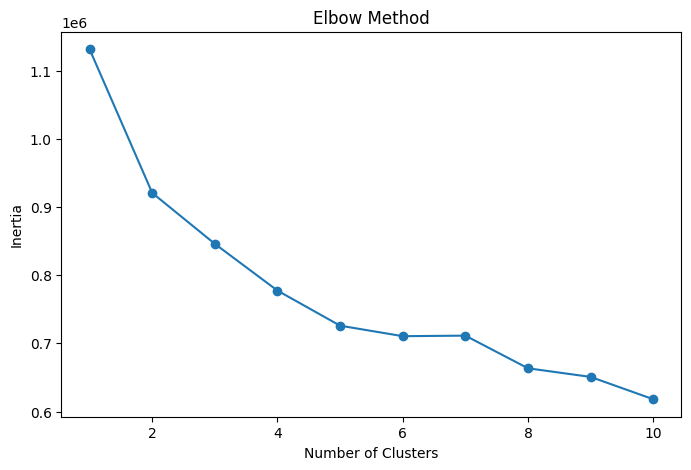

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("Cod_cwl_data.csv")

# Select numeric columns only
numeric_data = df.select_dtypes(include=['number'])

# Handle missing values
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(numeric_data)

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# Elbow method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

data["Cluster"] = clusters

data.head()

,Unnamed: 0,match id,series id,end time,duration (s),mode,map,team,player,win?,score,kills,deaths,+/-,k/d,kills per 10min,deaths per 10min,player score,player spm,damage dealt,ekia,assists,headshots,suicides,team kills,team deaths,kills (stayed alive),hits,shots,accuracy (%),num lives,time alive (s),avg time per life (s),fave weapon,fave specialist,fave scorestreaks,hill time (s),hill captures,hill defends,snd rounds,snd firstbloods,snd firstdeaths,snd survives,bomb pickups,bomb plants,bomb defuses,bomb sneak defuses,snd 1-kill round,snd 2-kill round,snd 3-kill round,snd 4-kill round,ctrl rounds,ctrl firstbloods,ctrl firstdeaths,ctrl captures,2-piece,3-piece,4-piece,4-streak,5-streak,6-streak,7-streak,8+-streak,fave division,fave training,ctf captures,ctf returns,ctf pickups,ctf defends,ctf kill carriers,ctf flag carry time (s),scorestreaks earned,scorestreaks used,scorestreaks deployed,scorestreaks kills,scorestreaks assists,Cluster
0,0,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Denz,L,93,10,17,-7,0.59,13.5,22.9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Seany,L,93,13,17,-4,0.76,17.5,22.9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Tommey,L,93,15,16,-1,0.94,20.2,21.5,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,3,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Wuskin,L,93,8,19,-11,0.42,10.8,25.6,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,4,missing-pro-w1-1-map-1,pro-w1-1,2019-02-04 18:22:38 UTC,446,Hardpoint,Arsenal,Reciprocity,Zed,L,93,17,15,2,1.13,22.9,20.2,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0%,0,0.0,?,NaN,NaN,NaN,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


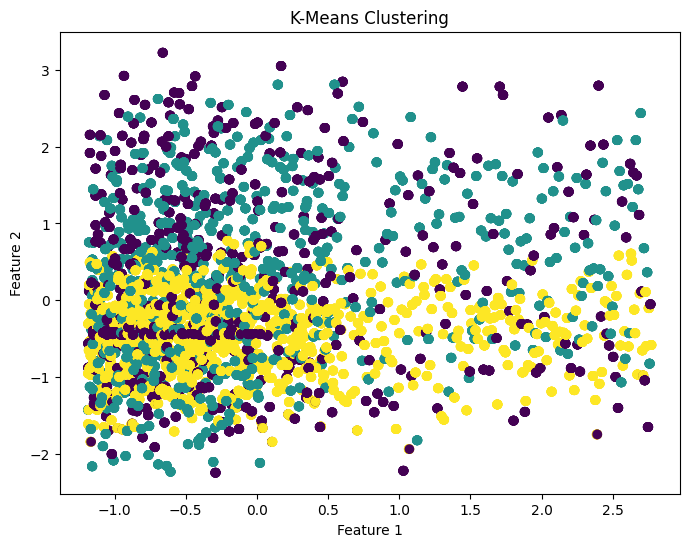

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:, 0],
    scaled_data[:, 1],
    c=data["Cluster"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

In [15]:
scaler = StandardScaler()

In [16]:
data.to_csv("Cod_cwl_clustered.csv", index=False)